In [51]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

In [52]:
# Enable automatic reloading of modules before executing cells
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
SCRIPT_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(SCRIPT_DIR)
ML_DIR = os.path.join(PARENT_DIR, "ml_scripts")
DATA_DIR = os.path.join(ML_DIR, "output")
ENSEMBLE_DATA_DIR = os.path.join(DATA_DIR, "ensemble")
POST_PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "2030_emissions")

In [54]:
# Load the data
run_id = 1773188058
iso_alpha_3 = "MEX"
df = pd.read_parquet(os.path.join(POST_PROCESSED_DATA_DIR, f"post_processed_projected_emissions_{run_id}.parquet"))
df.head()


,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918


In [55]:
# Filter the data for the specific country
df = df[df["iso_alpha_3"] == iso_alpha_3]

In [56]:
# First compute percentage difference between final year and 2022.

def compute_emissions_change(df, year1, year2, value_col):
    df_pivot = df.pivot(index=["future_id", "iso_alpha_3"], columns="year", values=value_col).reset_index()
    df_pivot.columns.name = None

    # ensure all column names are strings
    df_pivot.columns = df_pivot.columns.astype(str)

    df_pivot["change_abs"] = df_pivot[year2] - df_pivot[year1]
    df_pivot["change_sym"] = (
        (df_pivot[year2] - df_pivot[year1]) /
        ((df_pivot[year2].abs() + df_pivot[year1].abs()) / 2)
    )
    df_pivot = df_pivot[["future_id", "iso_alpha_3", year1, year2, "change_abs", "change_sym"]]
    return df_pivot

df_pivot = compute_emissions_change(df, "2022", "2030", "con_edgar_ghg_mt_hp_trend")
df_pivot.head()

,future_id,iso_alpha_3,2022,2030,change_abs,change_sym
0,id_MEX_1,MEX,787.671094,764.184443,-23.486651,-0.030269
1,id_MEX_10,MEX,787.671094,796.694486,9.023392,0.011391
2,id_MEX_100,MEX,787.671094,797.843480,10.172385,0.012832
3,id_MEX_1000,MEX,787.671094,829.957313,42.286218,0.052282
4,id_MEX_101,MEX,787.671094,874.880029,87.208935,0.104910


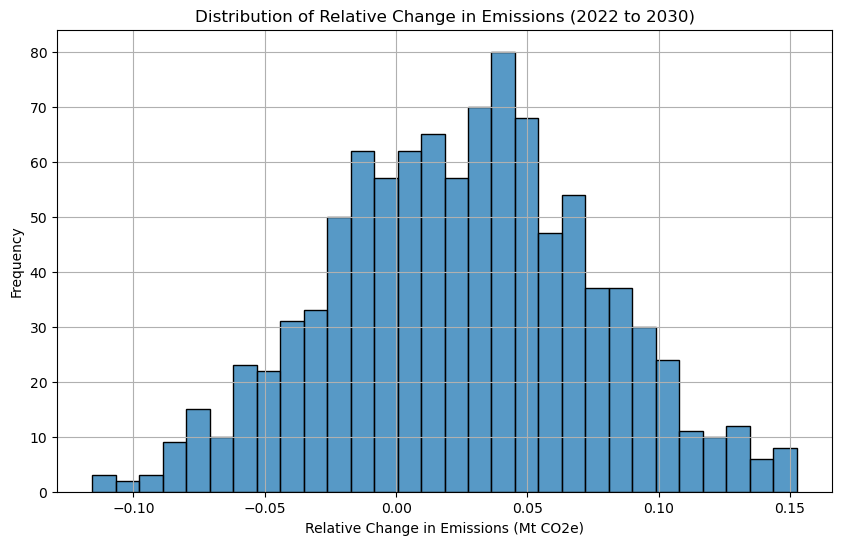

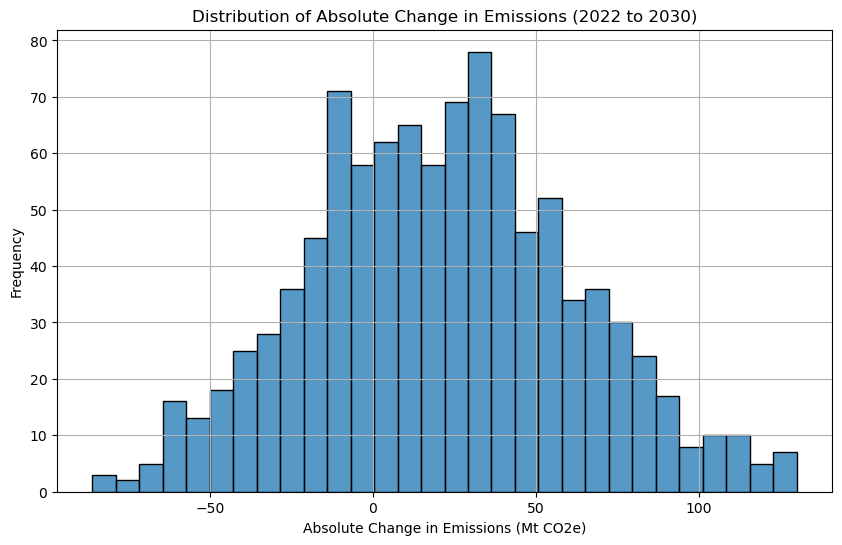

In [57]:
# Plot histogram of change_abs
def plot_histogram(df, column, title, xlabel, ylabel, remove_outliers=False):

    # Copy to avoid modifying the original DataFrame
    df_to_plot = df[[column]].copy()
    
    if remove_outliers:

        # Remove outliers using IQR
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        df_to_plot = df_to_plot[(df_to_plot[column] >= Q1 - 1.5 * IQR) & (df_to_plot[column] <= Q3 + 1.5 * IQR)]

    plt.figure(figsize=(10, 6))
    sns.histplot(df_to_plot[column], bins=30, kde=False)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    plt.show()


plot_histogram(df_pivot, "change_sym", "Distribution of Relative Change in Emissions (2022 to 2030)", "Relative Change in Emissions (Mt CO2e)", "Frequency")
plot_histogram(df_pivot, "change_abs", "Distribution of Absolute Change in Emissions (2022 to 2030)", "Absolute Change in Emissions (Mt CO2e)", "Frequency")

In [58]:
def create_quantile_bin_labels(
    df,
    target_col="change_abs",
    quantile_levels=None,
    dropna_target=True
):

    df_out = df.copy()

    if quantile_levels is None:
        quantile_levels = [i / 10 for i in range(1, 10)]

    # ---- Optional NA handling for quantile computation ----
    if dropna_target:
        target_series = df_out[target_col].dropna()
    else:
        target_series = df_out[target_col]

    # ---- Step 3: compute quantiles ----
    quantiles = target_series.quantile(quantile_levels)

    # ---- Step 4: build mapping ----
    threshold_map = {
        f"v{int(q * 100)}": threshold
        for q, threshold in quantiles.items()
    }

    # ---- Step 5: create binary flags ----
    for label, threshold in threshold_map.items():
        df_out[label] = (df_out[target_col] >= threshold).astype(int)

    # ---- Step 6: tidy threshold table ----
    threshold_df = pd.DataFrame(
        [
            {"label": label, "quantile": int(label[1:]) / 100, "threshold": threshold}
            for label, threshold in threshold_map.items()
        ]
    ).sort_values("quantile").reset_index(drop=True)

    # ---- Step 7: class balance summary ----
    class_balance_rows = []
    for label in threshold_map.keys():
        value_counts = df_out[label].value_counts(normalize=True, dropna=False)
        class_balance_rows.append({
            "label": label,
            "class_0_share": value_counts.get(0, 0.0),
            "class_1_share": value_counts.get(1, 0.0)
        })

    class_balance = pd.DataFrame(class_balance_rows)

    return {
        "df": df_out,
        "threshold_map": threshold_map,
        "threshold_df": threshold_df,
        "class_balance": class_balance
    }

In [59]:
results_dict = create_quantile_bin_labels(
    df=df_pivot,
    target_col="change_abs"
)

In [60]:
results_dict["df"].head()

,future_id,iso_alpha_3,2022,2030,change_abs,change_sym,v10,v20,v30,v40,v50,v60,v70,v80,v90
0,id_MEX_1,MEX,787.671094,764.184443,-23.486651,-0.030269,1,0,0,0,0,0,0,0,0
1,id_MEX_10,MEX,787.671094,796.694486,9.023392,0.011391,1,1,1,0,0,0,0,0,0
2,id_MEX_100,MEX,787.671094,797.843480,10.172385,0.012832,1,1,1,1,0,0,0,0,0
3,id_MEX_1000,MEX,787.671094,829.957313,42.286218,0.052282,1,1,1,1,1,1,1,0,0
4,id_MEX_101,MEX,787.671094,874.880029,87.208935,0.104910,1,1,1,1,1,1,1,1,1


In [61]:
# Load the projected data
ensemble_df = pd.read_parquet(os.path.join(ENSEMBLE_DATA_DIR, f"ensemble_arima_{run_id}.parquet"))
ensemble_df.head()

,iso_alpha_3,future_id,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,...,cap_govt_effectiveness,con_ndgain_score,emissions_anchor_2022,years_since_2022,trend_year_interaction,em_lag_1y,em_trend_3y,em_trend_5y,em_volatility_5y,em_acceleration
0,AFG,id_AFG_1,2022,3.405119,0.048790,0.0,0.0,5.880000,0.040182,0.0,...,-1.880035,32.633596,NaN,0.0,NaN,3.399653,-0.022348,-0.028681,0.050438,0.006334
1,AFG,id_AFG_1,2023,3.406011,0.055667,0.0,0.0,6.009763,0.000000,0.0,...,-2.028122,32.452377,NaN,1.0,NaN,3.400199,-0.018481,-0.027746,0.049581,0.006627
2,AFG,id_AFG_1,2024,3.395691,0.063294,0.0,0.0,6.157955,0.000000,0.0,...,-2.189786,33.519214,NaN,2.0,NaN,3.400289,-0.019795,-0.026254,0.047960,0.006346
3,AFG,id_AFG_1,2025,3.384084,0.070110,0.0,0.0,6.515455,0.000000,0.0,...,-2.319343,33.014896,NaN,3.0,NaN,3.399257,-0.020584,-0.025285,0.046763,0.006171
4,AFG,id_AFG_1,2026,3.391456,0.071661,0.0,0.0,6.538660,0.000000,0.0,...,-2.482714,34.419108,NaN,4.0,NaN,3.398096,-0.021209,-0.026219,0.046283,0.006201


In [62]:
ensemble_df.columns

Index(['iso_alpha_3', 'future_id', 'year', 'x_log_signed_con_edgar_ghg_mt',
       'x_log_signed_con_solar', 'inc_has_efficiency_standard',
       'inc_has_renewable_target', 'con_net_elec_imports_twh',
       'x_log_signed_cap_civil_liberties_idx', 'inc_has_carbon_tax',
       'inc_has_ets', 'x_log_signed_inc_carbon_pricing_coverage',
       'con_forest_area_pct', 'con_agricultural_land_pct',
       'x_log_signed_con_nuclear', 'x_log_signed_con_electricity_access_pct',
       'inc_has_framework_law', 'x_log_signed_inc_n_climate_laws',
       'x_log_signed_inc_cumulative_climate_laws', 'con_fossil_share_elec_pct',
       'con_renewables_share_elec_pct', 'x_log_signed_con_primary_energy_twh',
       'x_log_signed_con_hydro', 'x_log_signed_con_demand',
       'x_log_signed_con_coal', 'x_log_signed_con_gas',
       'x_log_signed_con_demand_per_capita', 'cap_regulatory_quality',
       'cap_rule_of_law', 'cap_govt_effectiveness', 'con_ndgain_score',
       'emissions_anchor_2022', 'years_s

In [63]:
# Aggregate ensemble data so we only get a single row per future_id

# First we remove all emisssion-related variables to avoid any sort of leakage
emission_cols = [
    'x_log_signed_con_edgar_ghg_mt',
    'emissions_anchor_2022', 
    'years_since_2022', 
    'trend_year_interaction',
    'em_lag_1y',
    'em_trend_3y',
    'em_trend_5y',
    'em_volatility_5y',
    'em_acceleration'
]

ensemble_df = ensemble_df.drop(columns=emission_cols, errors='ignore')

# Filter to only the country we're interested in
ensemble_df = ensemble_df[ensemble_df["iso_alpha_3"] == iso_alpha_3]

# Now we aggregate

def load_projection_rulebook(rules_path):
    with open(rules_path, 'r') as f:
        rulebook = json.load(f)

    category_map = {}
    for category, columns in rulebook.get('categories', {}).items():
        for col in columns:
            category_map[col] = category

    for col, category in rulebook.get('overrides', {}).items():
        category_map[col] = category

    prefix_rules = rulebook.get('prefix_rules', [])
    default_category = rulebook.get('default_category', 'unconstrained')
    return category_map, prefix_rules, default_category

def resolve_category(col, category_map, prefix_rules, default_category):
    if col in category_map:
        return category_map[col]
    for rule in prefix_rules:
        if col.startswith(rule['prefix']):
            return rule['category']
    return default_category

def _safe_std(values):
    if len(values) <= 1:
        return np.nan
    return float(np.std(values, ddof=1))

def _safe_slope(years, values):
    if len(values) <= 1:
        return np.nan
    return float(np.polyfit(years.astype(float), values.astype(float), 1)[0])

def summarize_trajectory(group, value_cols, category_map, prefix_rules, default_category):
    group = group.sort_values('year')
    row = {
        'future_id': group['future_id'].iloc[0],
        'iso_alpha_3': group['iso_alpha_3'].iloc[0],
        'year_start': int(group['year'].min()),
        'year_end': int(group['year'].max()),
        'n_years': int(group['year'].nunique()),
    }

    for col in value_cols:
        category = resolve_category(col, category_map, prefix_rules, default_category)
        valid = group[['year', col]].dropna()

        if valid.empty:
            continue

        years = valid['year'].to_numpy()
        values = valid[col].astype(float).to_numpy()
        prefix = f'{col}__'

        if category == 'binary':
            row[prefix + 'mean'] = float(values.mean())
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'max'] = float(values.max())
            row[prefix + 'switches'] = float(np.abs(np.diff(values)).sum()) if len(values) > 1 else 0.0
        elif category == 'cumulative_binary':
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'max'] = float(values.max())
        elif category == 'count':
            row[prefix + 'sum'] = float(values.sum())
            row[prefix + 'mean'] = float(values.mean())
            row[prefix + 'std'] = _safe_std(values)
            row[prefix + 'max'] = float(values.max())
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'delta'] = float(values[-1] - values[0])
            row[prefix + 'slope'] = _safe_slope(years, values)
        elif category == 'cumulative_count':
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'max'] = float(values.max())
            row[prefix + 'delta'] = float(values[-1] - values[0])
            row[prefix + 'slope'] = _safe_slope(years, values)
        else:
            row[prefix + 'mean'] = float(values.mean())
            row[prefix + 'std'] = _safe_std(values)
            row[prefix + 'min'] = float(values.min())
            row[prefix + 'max'] = float(values.max())
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'delta'] = float(values[-1] - values[0])
            row[prefix + 'slope'] = _safe_slope(years, values)

    return row

def aggregate_ensemble_by_future_id(
    ensemble_df,
    rules_path,
    group_col='future_id',
    keep_country_col='iso_alpha_3',
    year_col='year'
):
    category_map, prefix_rules, default_category = load_projection_rulebook(rules_path)

    id_cols = {group_col, keep_country_col, year_col}
    value_cols = [col for col in ensemble_df.columns if col not in id_cols]

    aggregated_rows = []
    for _, group in ensemble_df.groupby(group_col, sort=False):
        aggregated_rows.append(
            summarize_trajectory(group, value_cols, category_map, prefix_rules, default_category)
        )

    return pd.DataFrame(aggregated_rows)

rules_path = os.path.join(ML_DIR, 'config', 'variable_projection_rules.json')
ensemble_agg_df = aggregate_ensemble_by_future_id(ensemble_df, rules_path=rules_path)
ensemble_agg_df.head()

,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__mean,x_log_signed_con_solar__std,x_log_signed_con_solar__min,x_log_signed_con_solar__max,x_log_signed_con_solar__last,...,cap_govt_effectiveness__last,cap_govt_effectiveness__delta,cap_govt_effectiveness__slope,con_ndgain_score__mean,con_ndgain_score__std,con_ndgain_score__min,con_ndgain_score__max,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__slope
0,id_MEX_1,MEX,2022,2030,9,2.888264,0.316017,2.337952,3.228861,3.153228,...,-0.690586,-0.408863,-0.049805,45.187459,0.695513,43.916781,46.050706,45.399561,-0.346462,0.105335
1,id_MEX_10,MEX,2022,2030,9,3.076343,0.539645,2.337952,3.773056,3.773056,...,-0.916191,-0.634467,-0.078832,44.884441,1.500822,42.768358,47.752418,43.749064,-1.996959,-0.426157
2,id_MEX_100,MEX,2022,2030,9,2.268672,0.202818,1.993121,2.685267,2.685267,...,-0.378619,-0.096895,-0.012931,47.591395,3.149055,43.823727,52.783868,43.823727,-1.922296,-0.609375
3,id_MEX_1000,MEX,2022,2030,9,2.385828,0.210126,2.089729,2.625595,2.089729,...,-0.310199,-0.028475,-0.007892,44.017637,1.890886,41.537287,47.178064,41.537287,-4.208736,-0.379388
4,id_MEX_101,MEX,2022,2030,9,2.886270,0.296989,2.337952,3.300821,3.300821,...,-0.700028,-0.418304,-0.046117,45.301093,0.842952,44.060642,46.294423,44.899142,-0.846880,0.026911


In [64]:
ensemble_agg_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__mean', 'x_log_signed_con_solar__std',
       'x_log_signed_con_solar__min', 'x_log_signed_con_solar__max',
       'x_log_signed_con_solar__last',
       ...
       'cap_govt_effectiveness__last', 'cap_govt_effectiveness__delta',
       'cap_govt_effectiveness__slope', 'con_ndgain_score__mean',
       'con_ndgain_score__std', 'con_ndgain_score__min',
       'con_ndgain_score__max', 'con_ndgain_score__last',
       'con_ndgain_score__delta', 'con_ndgain_score__slope'],
      dtype='object', length=177)

In [65]:
# Merge the ensemble agg data with the quantile-labeled data
def merge_ensemble_with_quantiles(ensemble_agg_df, quantile_df, on_cols=["future_id"]):
    quantile_df_subset = quantile_df[on_cols + [col for col in quantile_df.columns if col.startswith("v")]]
    merged_df = pd.merge(ensemble_agg_df, quantile_df_subset, on=on_cols, how="left")
    # ensure the bin cols are integers (in case they got cast to floats during the merge)
    # use the nullable integer dtype so NaNs are preserved instead of raising on conversion
    for col in quantile_df_subset.columns:
        if col.startswith("v"):
            # coerce non-finite values to NaN, then cast to pandas nullable integer dtype
            merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce").astype("Int64")

    return merged_df
merged_df = merge_ensemble_with_quantiles(ensemble_agg_df, results_dict["df"], on_cols=["future_id"])
merged_df.head()

,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__mean,x_log_signed_con_solar__std,x_log_signed_con_solar__min,x_log_signed_con_solar__max,x_log_signed_con_solar__last,...,con_ndgain_score__slope,v10,v20,v30,v40,v50,v60,v70,v80,v90
0,id_MEX_1,MEX,2022,2030,9,2.888264,0.316017,2.337952,3.228861,3.153228,...,0.105335,1,0,0,0,0,0,0,0,0
1,id_MEX_10,MEX,2022,2030,9,3.076343,0.539645,2.337952,3.773056,3.773056,...,-0.426157,1,1,1,0,0,0,0,0,0
2,id_MEX_100,MEX,2022,2030,9,2.268672,0.202818,1.993121,2.685267,2.685267,...,-0.609375,1,1,1,1,0,0,0,0,0
3,id_MEX_1000,MEX,2022,2030,9,2.385828,0.210126,2.089729,2.625595,2.089729,...,-0.379388,1,1,1,1,1,1,1,0,0
4,id_MEX_101,MEX,2022,2030,9,2.886270,0.296989,2.337952,3.300821,3.300821,...,0.026911,1,1,1,1,1,1,1,1,1


In [66]:
merged_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__mean', 'x_log_signed_con_solar__std',
       'x_log_signed_con_solar__min', 'x_log_signed_con_solar__max',
       'x_log_signed_con_solar__last',
       ...
       'con_ndgain_score__slope', 'v10', 'v20', 'v30', 'v40', 'v50', 'v60',
       'v70', 'v80', 'v90'],
      dtype='object', length=186)

In [70]:
# Then we train the rando forests to predict each of the binary variables and we compute the feature importance.
# We only care about those that are above 0.5 feature importance.

# Filter out irrelevant columns for modeling
non_modeling_cols = [
    "future_id",
    "iso_alpha_3",
    "year_start",
    "year_end",
    "n_years"
]

target_cols = [col for col in merged_df.columns if col.startswith("v")]
feature_cols = [col for col in merged_df.columns if col not in non_modeling_cols + target_cols]

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_all = merged_df[feature_cols].apply(pd.to_numeric, errors="coerce")

rf_models = {}
rf_training_rows = []
feature_importance_rows = []
importance_threshold = 0.01
test_size = 0.2

for target_col in target_cols:
    y = pd.to_numeric(merged_df[target_col], errors="coerce")
    valid_mask = y.notna()

    X_target = X_all.loc[valid_mask].copy()
    y_target = y.loc[valid_mask].astype(int)

    if X_target.empty or y_target.nunique() < 2:
        rf_training_rows.append({
            "target_col": target_col,
            "n_rows": int(len(y_target)),
            "class_0": int((y_target == 0).sum()),
            "class_1": int((y_target == 1).sum()),
            "status": "skipped_insufficient_class_variation"
        })
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_target,
        y_target,
        test_size=test_size,
        random_state=42,
        stratify=y_target
    )

    eval_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
            min_samples_leaf=2
        ))
    ])

    eval_model.fit(X_train, y_train)
    y_pred = eval_model.predict(X_test)
    y_proba = eval_model.predict_proba(X_test)[:, 1]

    final_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
            min_samples_leaf=2
        ))
    ])
    final_model.fit(X_target, y_target)
    rf_models[target_col] = final_model

    rf = final_model.named_steps["rf"]
    importances = rf.feature_importances_
    n_above_threshold = int((importances > importance_threshold).sum())
    max_importance = float(importances.max())
    mean_importance = float(importances.mean())
    median_importance = float(np.median(importances))
    baseline_accuracy = float(max((y_test == 0).mean(), (y_test == 1).mean()))
    roc_auc = float(roc_auc_score(y_test, y_proba)) if y_test.nunique() == 2 else np.nan

    rf_training_rows.append({
        "target_col": target_col,
        "n_rows": int(len(y_target)),
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "class_0": int((y_target == 0).sum()),
        "class_1": int((y_target == 1).sum()),
        "status": "trained",
        "n_features": int(len(feature_cols)),
        "baseline_accuracy": baseline_accuracy,
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "test_precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "test_recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "test_f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "test_roc_auc": roc_auc,
        "mean_importance": mean_importance,
        "median_importance": median_importance,
        "max_importance": max_importance,
        "n_features_above_threshold": n_above_threshold,
        "share_features_above_threshold": float(n_above_threshold / len(feature_cols))
    })

    for feature_name, importance in zip(feature_cols, importances):
        feature_importance_rows.append({
            "target_col": target_col,
            "feature": feature_name,
            "importance": float(importance),
            "above_threshold": bool(importance > importance_threshold)
        })

rf_training_summary_df = pd.DataFrame(rf_training_rows).sort_values("target_col").reset_index(drop=True)
feature_importance_df = pd.DataFrame(feature_importance_rows)
top_feature_importance_df = (
    feature_importance_df[feature_importance_df["above_threshold"]]
    .sort_values(["target_col", "importance"], ascending=[True, False])
    .reset_index(drop=True)
)
importance_threshold_summary_df = pd.DataFrame([
    {
        "importance_threshold": importance_threshold,
        "test_size": test_size,
        "n_targets_trained": int((rf_training_summary_df["status"] == "trained").sum()),
        "mean_baseline_accuracy": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "baseline_accuracy"].mean(),
        "mean_test_accuracy": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "test_accuracy"].mean(),
        "mean_test_balanced_accuracy": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "test_balanced_accuracy"].mean(),
        "mean_test_f1": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "test_f1"].mean(),
        "mean_test_roc_auc": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "test_roc_auc"].mean(),
        "mean_of_target_mean_importance": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "mean_importance"].mean(),
        "mean_of_target_median_importance": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "median_importance"].mean(),
        "mean_of_target_max_importance": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "max_importance"].mean(),
        "max_feature_importance_overall": feature_importance_df["importance"].max() if not feature_importance_df.empty else np.nan,
        "mean_features_above_threshold_per_target": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "n_features_above_threshold"].mean(),
        "mean_share_features_above_threshold_per_target": rf_training_summary_df.loc[rf_training_summary_df["status"] == "trained", "share_features_above_threshold"].mean(),
        "n_feature_rows_above_threshold": int(feature_importance_df["above_threshold"].sum()) if not feature_importance_df.empty else 0,
        "share_feature_rows_above_threshold": feature_importance_df["above_threshold"].mean() if not feature_importance_df.empty else np.nan
    }
])

rf_training_summary_df


,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance,n_features_above_threshold,share_features_above_threshold
0,v10,998,798,200,100,898,trained,172,0.9,0.910,0.572222,0.913265,0.994444,0.952128,0.935000,0.005814,0.002909,0.044370,30,0.174419
1,v20,998,798,200,200,798,trained,172,0.8,0.875,0.687500,0.864865,1.000000,0.927536,0.920156,0.005814,0.003190,0.034081,31,0.180233
2,v30,998,798,200,300,698,trained,172,0.7,0.855,0.767857,0.836364,0.985714,0.904918,0.950357,0.005814,0.003227,0.034650,32,0.186047
3,v40,998,798,200,399,599,trained,172,0.6,0.845,0.827083,0.839695,0.916667,0.876494,0.933021,0.005814,0.003163,0.034633,32,0.186047
4,v50,998,798,200,499,499,trained,172,0.5,0.865,0.865000,0.847619,0.890000,0.868293,0.929300,0.005814,0.003190,0.037599,31,0.180233
5,v60,998,798,200,599,399,trained,172,0.6,0.875,0.858333,0.898551,0.775000,0.832215,0.960000,0.005814,0.003281,0.034586,34,0.197674
6,v70,998,798,200,698,300,trained,172,0.7,0.840,0.742857,0.937500,0.500000,0.652174,0.938452,0.005814,0.003240,0.034761,32,0.186047
7,v80,998,798,200,798,200,trained,172,0.8,0.870,0.675000,1.000000,0.350000,0.518519,0.920781,0.005814,0.003005,0.047823,35,0.203488
8,v90,998,798,200,898,100,trained,172,0.9,0.900,0.500000,0.000000,0.000000,0.000000,0.955556,0.005814,0.002922,0.045405,31,0.180233


In [71]:
# We calculate the number of times each top variables shows up across the different feature importances
top_feature_counts_df = (
    top_feature_importance_df.groupby("feature")
    .agg(
        n_targets=("target_col", "nunique"),
        mean_importance=("importance", "mean"),
        max_importance=("importance", "max")
    )
    .sort_values(["n_targets", "mean_importance", "max_importance"], ascending=[False, False, False])
    .reset_index()
)

importance_threshold_summary_df


,importance_threshold,test_size,n_targets_trained,mean_baseline_accuracy,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_f1,mean_test_roc_auc,mean_of_target_mean_importance,mean_of_target_median_importance,mean_of_target_max_importance,max_feature_importance_overall,mean_features_above_threshold_per_target,mean_share_features_above_threshold_per_target,n_feature_rows_above_threshold,share_feature_rows_above_threshold
0,0.01,0.2,9,0.722222,0.870556,0.721761,0.725808,0.938069,0.005814,0.003125,0.038657,0.047823,32.0,0.186047,288,0.186047


In [72]:
top_feature_counts_df

,feature,n_targets,mean_importance,max_importance
0,x_log_signed_con_demand_per_capita__slope,9,0.035402,0.047823
1,x_log_signed_con_demand_per_capita__last,9,0.032633,0.044370
2,con_fossil_share_elec_pct__slope,9,0.032335,0.037599
3,x_log_signed_con_demand_per_capita__delta,9,0.030399,0.041980
4,x_log_signed_con_demand_per_capita__max,9,0.027200,0.032944
5,con_fossil_share_elec_pct__last,9,0.025614,0.032222
6,x_log_signed_con_primary_energy_twh__slope,9,0.024466,0.034422
7,con_fossil_share_elec_pct__delta,9,0.023870,0.026560
8,x_log_signed_con_demand_per_capita__mean,9,0.022701,0.028940
9,con_fossil_share_elec_pct__min,9,0.022204,0.026290
